---

## **K-Means Clustering**  

---

### **1. Introducción al Clustering**  
- **Definición**: El clustering es una técnica de aprendizaje no supervisado que agrupa datos similares en categorías sin etiquetas previas.  
- **Aplicaciones**:  
  - Segmentación de clientes en marketing.  
  - Agrupación de imágenes en visión por computadora.  
  - Detección de patrones en datos biomédicos.  
- **Tipos de Clustering**:  
  - **Particional** (como K-Means) → Divide en "K" grupos.  
  - **Jerárquico** → Crea una estructura de árbol.  

---

### **2. ¿Qué es K-Means?**  
- **Definición**: K-Means es un algoritmo que agrupa datos en "K" clusters, donde cada punto pertenece al cluster con el centroide más cercano.  
- **Proceso del algoritmo**:  
  1. **Elegir "K"** (número de clusters).  
  2. **Inicializar centroides** (aleatoriamente o usando métodos como K-Means++).  
  3. **Asignar cada punto al cluster más cercano** (mínima distancia euclidiana).  
  4. **Actualizar centroides** (promedio de los puntos en cada cluster).  
  5. **Repetir hasta convergencia** (cuando los centroides dejan de moverse significativamente).  

---

### **3. Implementación en Python**
Ejemplo práctico usando **Scikit-Learn**:


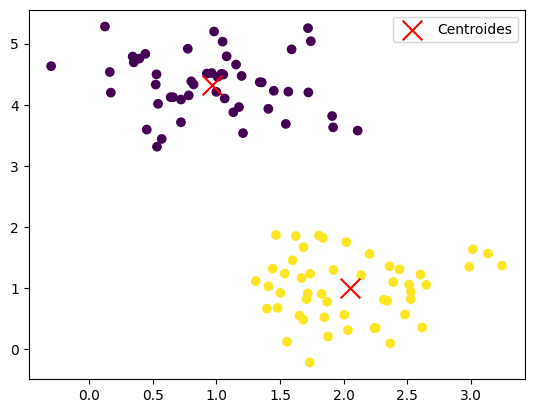

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# Datos de ejemplo (puntos en 2D)
# X = np.array([[1, 2], [1, 4], [1, 0],
#               [10, 2], [10, 4], [10, 0]])
from sklearn.datasets import make_blobs
X, y = make_blobs(centers=2, cluster_std=0.5, random_state=0)

# Definir número de clusters
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)

# Entrenar el modelo
kmeans.fit(X)

# Etiquetas asignadas a los datos
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualizar los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroides')
plt.legend()
plt.show()


Explica:  
- Cómo el algoritmo encuentra los clusters.  
- El significado de `labels_` y `cluster_centers_`.  
- El impacto de cambiar "K".  

---

### **4. Selección del Mejor K**

Determinar el número óptimo de clusters es clave en **K-Means**. Se pueden usar varios métodos, como:  

#### **📌 Método del Codo (Elbow Method)**  
- Basado en la **inercia** (suma de distancias cuadradas de cada punto a su centroide).  
- Se elige el punto donde la disminución de inercia se ralentiza ("punto de inflexión" o "codo").  

Ejemplo en Python:


range(1, 5)
1
2
3
4


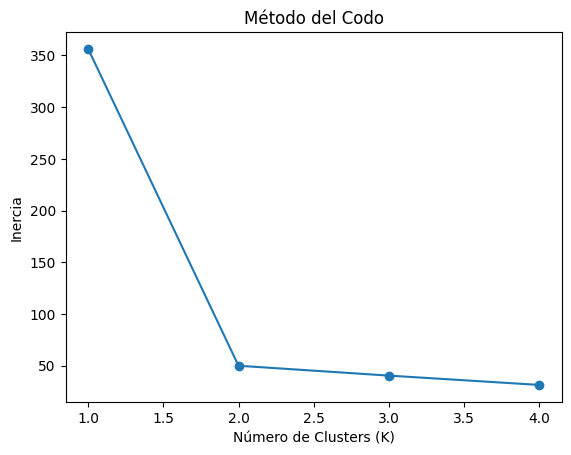

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Datos de ejemplo
# X = np.array([[1, 2], [1, 4], [1, 0],
#               [10, 2], [10, 4], [10, 0]])

from sklearn.datasets import make_blobs
X, y = make_blobs(centers=2, cluster_std=0.5, random_state=0)


# Evaluar inercia para diferentes valores de K
inertia = []
K_range = range(1, 5)
print(K_range)
for k in K_range:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
    inertia.append(kmeans.inertia_)

# Gráfico del método del codo
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()


✅ **Ventaja**: Fácil de interpretar visualmente.  
❌ **Desventaja**: Puede ser subjetivo porque el "codo" no siempre es claro.  

---

#### **📌 Método del Coeficiente de Silhouette**  
- Evalúa **qué tan bien** están agrupados los puntos comparando la distancia intra-cluster con la distancia inter-cluster.  
- Se calcula el coeficiente de Silhouette para cada punto como:  
  \[
  S = \frac{b - a}{\max(a, b)}
  \]
  donde:  
  - \(a\) es la distancia promedio del punto a los demás puntos de su propio cluster.  
  - \(b\) es la distancia promedio del punto al cluster más cercano.  
- El **valor óptimo de K** es el que maximiza el promedio del coeficiente Silhouette.  

Ejemplo en Python:


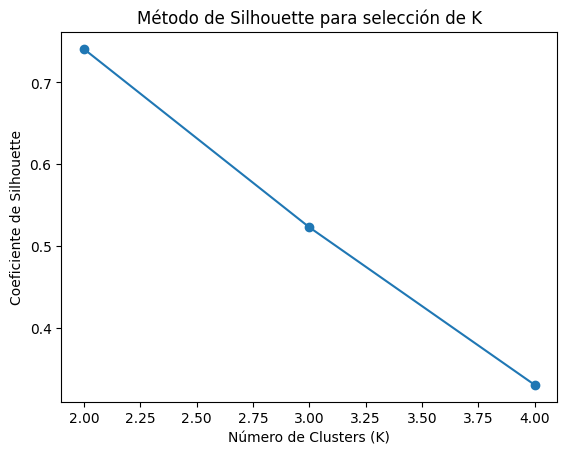

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 5):  # Se empieza en 2 porque con K=1 no hay comparación posible
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X, labels))

# Gráfico del coeficiente de Silhouette
plt.plot(range(2, 5), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Método de Silhouette para selección de K')
plt.show()


✅ **Ventaja**: Mide la calidad de los clusters de manera objetiva.  
❌ **Desventaja**: Más costoso computacionalmente que el método del codo.  

---

### **📊 Diferencias entre Elbow y Silhouette**  

| Método | Basado en | Ventaja | Desventaja |
|--------|----------|---------|------------|
| **Elbow (Codo)** | Inercia (distancias al centroide) | Rápido y fácil de visualizar | Puede ser subjetivo |
| **Silhouette** | Distancia intra e inter-cluster | Más preciso en la calidad del clustering | Computacionalmente más costoso |

🔹 **Conclusión**:  
- **Elbow Method** es útil para un análisis inicial.  
- **Silhouette** proporciona un criterio más sólido cuando se quiere asegurar una buena calidad de clustering.  

---





---

### **5. Ventajas y Desventajas de K-Means**
✅ **Ventajas**  
- Rápido y eficiente en conjuntos de datos grandes.  
- Fácil de interpretar y aplicar.  

❌ **Desventajas**  
- Sensible a la inicialización de centroides.  
- Depende de elegir un buen "K".  
- No funciona bien con clusters de formas no esféricas.  

---

### **Materiales Adicionales**  
📌 [Documentación oficial de Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)  
📌 [Explicación interactiva de K-Means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)  

---

---

## **Condiciones que deben cumplir los datos para que K-Means funcione de manera efectiva**

---

### **1️⃣ Forma de los Clusters: Deben ser Esféricos o Bien Separados**  
🔹 **Condición**: K-Means asume que los clusters son aproximadamente esféricos (de forma circular en 2D o esférica en 3D) y tienen un tamaño similar.  

🔹 **Problema**:  
- Si los clusters tienen formas alargadas o irregulares, K-Means puede asignar puntos incorrectamente.  
- Por ejemplo, si los datos tienen una forma de "media luna" o están interconectados, K-Means no los separará bien.  

🔹 **Solución**:  
- Usar otro algoritmo como **DBSCAN** o **clustering jerárquico**, que funcionan mejor con clusters de formas complejas.  

✅ **Funciona bien en:**  
✔ Datos con clusters compactos y bien separados.  
❌ **Mal desempeño en:**  
✘ Datos con formas irregulares o superpuestos.  

---

### **2️⃣ La Escala de los Datos Importa (Requiere Normalización)**  
🔹 **Condición**: K-Means usa **distancias euclidianas**, por lo que **la escala de las variables influye en la agrupación**.  

🔹 **Problema**:  
- Si una variable tiene valores mucho más grandes que otra, dominará la distancia.  
- Ejemplo: Un dataset con "altura (cm)" y "peso (kg)" → si no se normaliza, los valores del peso (generalmente más grandes) afectarán más la clasificación.  

🔹 **Solución**:  
- Normalizar los datos con **Min-Max Scaling** o **Estandarización (Z-score)**.  

Ejemplo en Python:  


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Normaliza los datos antes de aplicar K-Means


✅ **Funciona bien en:**  
✔ Datos normalizados o escalados.  
❌ **Mal desempeño en:**  
✘ Datos sin escalamiento cuando las variables tienen rangos muy diferentes.  

---

### **3️⃣ No Debe Haber Demasiado Ruido o Datos Atípicos (Outliers)**  
🔹 **Condición**: K-Means es sensible a **outliers** porque estos pueden distorsionar los centroides.  

🔹 **Problema**:  
- Un solo outlier puede cambiar la posición del centroide, afectando la asignación de clusters.  
- Ejemplo: En datos de ingresos de personas, un multimillonario puede arrastrar el centroide del cluster de ingresos medios.  

🔹 **Solución**:  
- Detectar y eliminar outliers antes de aplicar K-Means.  
- Usar **K-Medoids** en lugar de K-Means, ya que es más robusto frente a valores atípicos.  

Ejemplo de detección de outliers:  


In [30]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor()
outliers = lof.fit_predict(X)  # -1 indica un outlier
X_cleaned = X[outliers != -1]  # Filtrar outliers antes de usar K-Means


✅ **Funciona bien en:**  
✔ Datos sin valores atípicos significativos.  
❌ **Mal desempeño en:**  
✘ Datos con outliers que pueden distorsionar los centroides.  

---

### **4️⃣ Número Adecuado de Clusters (K) Debe Ser Elegido Correctamente**  
🔹 **Condición**: Elegir un **K correcto** es fundamental.  

🔹 **Problema**:  
- Un valor de **K muy pequeño** agrupará datos diferentes en un mismo cluster.  
- Un **K muy grande** dividirá demasiado los datos, perdiendo patrones importantes.  

🔹 **Solución**:  
- Usar **métodos como Elbow o Silhouette** para encontrar el mejor valor de K (como explicamos antes).  

✅ **Funciona bien en:**  
✔ Datos donde K se elige correctamente.  
❌ **Mal desempeño en:**  
✘ Datos con un número incorrecto de clusters.  

---

### **5️⃣ Los Datos No Deben Tener Demasiadas Dimensiones**  
🔹 **Condición**: K-Means no funciona bien en **datos con muchas dimensiones** (**curse of dimensionality**).  

🔹 **Problema**:  
- En espacios de alta dimensión, las distancias euclidianas pierden significado, lo que hace que K-Means tenga problemas para encontrar clusters correctos.  

🔹 **Solución**:  
- Aplicar reducción de dimensionalidad antes de usar K-Means, por ejemplo, con **PCA (Análisis de Componentes Principales)**:  

Ejemplo en Python:  


In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)  # Reducimos a 2 dimensiones
X_reduced = pca.fit_transform(X)


✅ **Funciona bien en:**  
✔ Datos de pocas dimensiones o después de aplicar reducción de dimensionalidad.  
❌ **Mal desempeño en:**  
✘ Datos de alta dimensión sin preprocesamiento.  

---

### **🔎 Resumen de Condiciones para que K-Means Funcione Bien**  

| Condición | Problema si no se cumple | Solución |
|-----------|-------------------------|----------|
| **Clusters esféricos y bien separados** | Mal agrupamiento si los clusters tienen formas irregulares. | Usar DBSCAN o clustering jerárquico. |
| **Datos normalizados** | Variables con escalas diferentes afectan la clasificación. | Aplicar `StandardScaler` o `MinMaxScaler`. |
| **Sin outliers** | Los outliers pueden distorsionar los centroides. | Detectar y eliminar outliers antes de aplicar K-Means. |
| **Número adecuado de clusters (K)** | Un K mal elegido genera clusters incorrectos. | Usar métodos como Elbow o Silhouette. |
| **Datos de baja dimensión** | K-Means pierde precisión en datos de alta dimensión. | Aplicar reducción de dimensionalidad (PCA). |

---

🔹 **Conclusión:**  
Si los datos cumplen estas condiciones, **K-Means será una excelente opción**. Si no, es mejor considerar **otros algoritmos como DBSCAN o clustering jerárquico**.  

---

---

## **Comprobar si los clusters son esféricos**

---

## **1️⃣ Visualización en 2D o 3D**  
📌 **Método**: Si los datos tienen **dos o tres dimensiones**, puedes graficar los clusters y observar su forma.  

Ejemplo en Python (con datos 2D):  


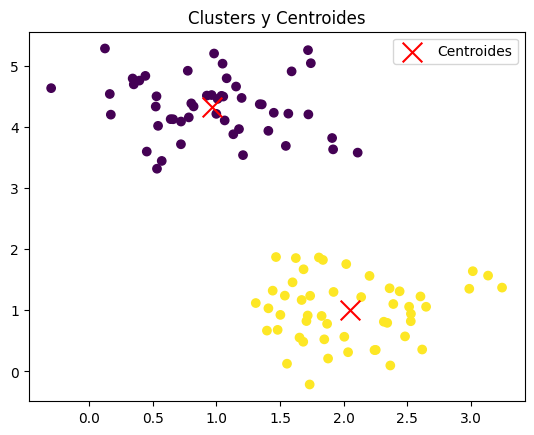

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Datos de ejemplo
#X = np.array([[1, 2], [1, 4], [1, 0], [10, 2], [10, 4], [10, 0]])

from sklearn.datasets import make_blobs
X, y = make_blobs(centers=2, cluster_std=0.5, random_state=0)


# Aplicar K-Means con K=2
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Graficar los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroides')
plt.legend()
plt.title("Clusters y Centroides")
plt.show()


✅ **Si los clusters son esféricos**, los datos formarán grupos compactos en torno a los centroides.  
❌ **Si los clusters son alargados o irregulares**, K-Means no será la mejor opción.  

---

## **2️⃣ Medición de la Dispersión dentro del Cluster**  
📌 **Método**: Se puede analizar la dispersión interna de cada cluster calculando la **varianza** de las distancias al centroide.  

Ejemplo en Python:  


In [33]:
from sklearn.metrics import pairwise_distances

def cluster_sphericity(X, labels, centroids):
    for i in range(len(centroids)):
        cluster_points = X[labels == i]  # Extrae los puntos del cluster i
        distances = pairwise_distances(cluster_points, [centroids[i]])  # Distancias al centroide
        variance = np.var(distances)  # Varianza de las distancias
        print(f"Cluster {i}: Varianza de distancias = {variance:.4f}")

# Aplicar K-Means
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Evaluar sphericity
cluster_sphericity(X, labels, centroids)

Cluster 0: Varianza de distancias = 0.1174
Cluster 1: Varianza de distancias = 0.0701



✅ **Si la varianza es baja**, significa que los puntos están agrupados de manera esférica.  
❌ **Si la varianza es alta**, el cluster podría tener una forma alargada o irregular.  

---

## **3️⃣ Uso del Índice de Silhouette para Evaluar la Forma de los Clusters**  
📌 **Método**:  
- El **coeficiente de Silhouette** mide qué tan bien está cada punto dentro de su cluster.  
- Si los valores de Silhouette son **altos y consistentes**, los clusters son más compactos y esféricos.  
- Si los valores varían mucho, puede indicar que algunos clusters tienen formas alargadas.  

Ejemplo en Python:  


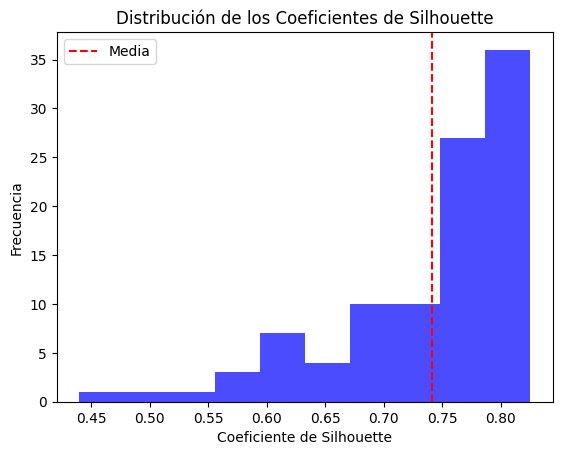

In [34]:
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X, kmeans.labels_)

# Visualización de Silhouette para cada punto
plt.hist(silhouette_vals, bins=10, color='blue', alpha=0.7)
plt.axvline(np.mean(silhouette_vals), color='red', linestyle='--', label="Media")
plt.xlabel("Coeficiente de Silhouette")
plt.ylabel("Frecuencia")
plt.title("Distribución de los Coeficientes de Silhouette")
plt.legend()
plt.show()



✅ **Si la mayoría de los valores están cerca de 1**, los clusters son compactos y esféricos.  
❌ **Si hay muchos valores cercanos a 0 o negativos**, los clusters tienen formas irregulares o solapadas.  

---

## **4️⃣ Test de Isotropía: Análisis de Covarianza dentro del Cluster**  
📌 **Método**:  
- Si un cluster es esférico, su **matriz de covarianza** debería ser aproximadamente diagonal (las variables no están correlacionadas).  
- Si hay correlaciones fuertes, el cluster tiene una forma alargada en alguna dirección.  

Ejemplo en Python:  


Matriz de Covarianza del Cluster 0:
[[ 0.27593283 -0.04179818]
 [-0.04179818  0.23673118]]



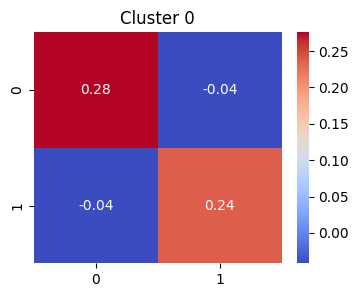

Matriz de Covarianza del Cluster 1:
[[0.24278635 0.01945809]
 [0.01945809 0.26566112]]



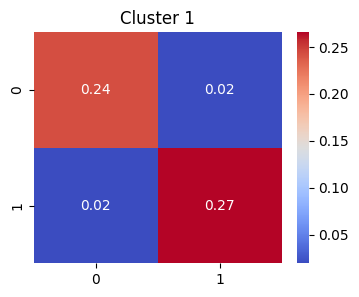

In [35]:
import seaborn as sns
import pandas as pd

# Convertir datos en DataFrame para facilidad de uso
df = pd.DataFrame(X, columns=["X1", "X2"])
df["Cluster"] = labels

# Calcular la matriz de covarianza dentro de cada cluster
for i in range(len(centroids)):
    cluster_data = df[df["Cluster"] == i][["X1", "X2"]]
    cov_matrix = np.cov(cluster_data.T)
    print(f"Matriz de Covarianza del Cluster {i}:\n{cov_matrix}\n")

    # Visualizar matriz de covarianza con mapa de calor
    plt.figure(figsize=(4, 3))
    sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Cluster {i}")
    plt.show()


✅ **Si la matriz de covarianza es casi diagonal**, el cluster es esférico.  
❌ **Si hay valores fuera de la diagonal significativos**, el cluster está alargado en alguna dirección.  

---

### **🔎 Conclusión: Métodos para Verificar la Forma de los Clusters**  

| Método | ¿Qué analiza? | Indicación de Clusters No Esféricos |
|--------|--------------|--------------------------------------|
| **Visualización 2D/3D** | Forma general del cluster | Se observan formas alargadas o irregulares |
| **Varianza de distancias al centroide** | Qué tan dispersos están los puntos dentro del cluster | Alta varianza indica formas alargadas |
| **Coeficiente de Silhouette** | Qué tan bien está definido cada cluster | Valores negativos o cercanos a 0 |
| **Matriz de Covarianza** | Correlación entre variables dentro de un cluster | Valores grandes fuera de la diagonal |

🔹 **Si los clusters no son esféricos**, considera otros algoritmos como:  
✔ **DBSCAN** → Si los clusters tienen formas irregulares.  
✔ **GMM (Gaussian Mixture Models)** → Si los clusters tienen varianza diferente en cada dirección.  

---

---

## **📊 Métodos de Verificación de Clusters con Ground Truth**  

---

### **1️⃣ Precisión, Recall y F1-Score (Tomado de los métodos supervisados - Si hay una correspondencia clara)**  
📌 **Cuándo usarlo**:  
- Si los clusters generados por K-Means tienen una correspondencia clara con las clases reales.  

📌 **Cómo funciona**:  
- Se trata como un problema de clasificación y se calculan **precisión**, **recall** y **F1-score** entre etiquetas reales y predichas.  
- Se necesita una correspondencia entre clusters y clases reales.  
- Se usa **accuracy_score** si los clusters se alinean bien con las clases.  

Ejemplo en Python:


In [36]:
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import mode

# Suponiendo que tenemos etiquetas reales `y_true` y etiquetas de K-Means `y_pred`
def map_clusters_to_labels(y_true, y_pred):
    new_labels = np.zeros_like(y_pred)
    for cluster in np.unique(y_pred):
        mask = y_pred == cluster
        new_labels[mask] = mode(y_true[mask])[0]  # Asignar la clase más frecuente del cluster
    return new_labels

# Etiquetas reales (ground truth)
y_true = y #np.array([0, 0, 1, 1, 0, 1])  # Ejemplo simple
y_pred = labels # np.array([1, 1, 0, 0, 1, 0])  # Clusters asignados por K-Means

# Asignar las etiquetas correctas a los clusters
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

# Evaluar la calidad del clustering
print("Accuracy:", accuracy_score(y_true, y_pred_mapped))
print(classification_report(y_true, y_pred_mapped))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100




✅ **Ventaja**: Permite medir el desempeño con métricas clásicas de clasificación.  
❌ **Desventaja**: Solo funciona si los clusters y clases reales están bien alineados.  

---

### **2️⃣ Matriz de Confusión (Tomado de los métos supervisados - Para analizar la correspondencia entre Clusters y Clases)**  
📌 **Cuándo usarlo**:  
- Si los clusters **no coinciden perfectamente con las clases**, pero queremos analizar las relaciones.  

📌 **Cómo funciona**:  
- Se crea una **matriz de confusión** para ver cómo los clusters predichos se corresponden con las clases reales.  

Ejemplo en Python:


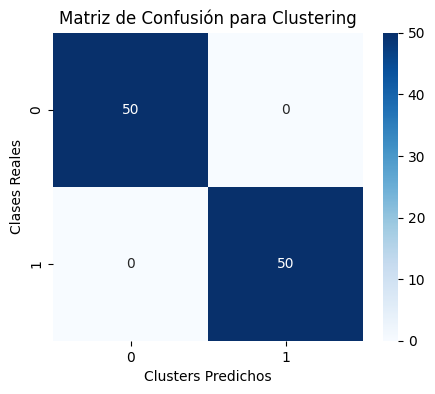

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generar matriz de confusión
cm = confusion_matrix(y_true, y_pred_mapped)

# Visualizar la matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Clusters Predichos")
plt.ylabel("Clases Reales")
plt.title("Matriz de Confusión para Clustering")
plt.show()


✅ **Ventaja**: Permite identificar confusiones y relaciones entre clusters y clases.  
❌ **Desventaja**: No da una métrica única de calidad.  

---

### **3️⃣ Rand Index y Adjusted Rand Index (ARI)**  
📌 **Cuándo usarlo**:  
- Cuando los clusters pueden tener estructuras complejas y no coinciden exactamente con las clases.  

📌 **Cómo funciona**:  
- **Rand Index (RI)** mide cuántos pares de puntos están correctamente agrupados o separados.  
- **Adjusted Rand Index (ARI)** ajusta RI para penalizar la aleatoriedad.  

Ejemplo en Python:


In [38]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(y_true, y_pred)
print(f"Adjusted Rand Index: {ari_score:.4f}")

Adjusted Rand Index: 1.0000



✅ **Ventaja**: Funciona bien incluso si los clusters tienen tamaños diferentes.  
❌ **Desventaja**: No da información sobre qué clusters están mal asignados.  

---

### **4️⃣ Normalized Mutual Information (NMI)**  
📌 **Cuándo usarlo**:  
- Si se quiere medir **qué tanta información** comparten los clusters con las clases reales.  

📌 **Cómo funciona**:  
- Calcula cuánta **entropía** (información) de las etiquetas reales está presente en los clusters predichos.  
- **Valores cercanos a 1** indican que el clustering es casi perfecto.  

Ejemplo en Python:


In [39]:
from sklearn.metrics import normalized_mutual_info_score

nmi_score = normalized_mutual_info_score(y_true, y_pred)
print(f"Normalized Mutual Information: {nmi_score:.4f}")


Normalized Mutual Information: 1.0000



✅ **Ventaja**: Invariante al número de clusters y escalable a grandes datasets.  
❌ **Desventaja**: No indica **cómo** están distribuidos los errores, solo la calidad general.  

---

### **📊 Comparación de Métodos**  

| **Métrica** | **¿Qué mide?** | **Valores altos indican...** | **Casos ideales de uso** |
|-------------|--------------|-----------------------------|-------------------------|
| **Accuracy / F1-Score** | Precisión en la clasificación de los clusters | Clusters coinciden con las clases reales | Cuando los clusters y clases tienen buena correspondencia |
| **Matriz de Confusión** | Relación entre clusters y clases | Buena alineación entre clusters y clases | Para analizar discrepancias entre clusters y clases |
| **Adjusted Rand Index (ARI)** | Agrupamiento correcto de pares de datos | Clusters bien estructurados | Para evaluar la calidad del clustering sin depender del número de clusters |
| **Normalized Mutual Information (NMI)** | Relación entre la información de clusters y clases reales | Fuerte relación entre clusters y clases | Para evaluar si los clusters contienen información relevante de las clases |

---

## **🔎 Conclusión**  

✔ Si los clusters coinciden con las clases reales → **Precisión, F1-score, Matriz de Confusión**.  
✔ Si los clusters tienen estructuras complejas → **ARI y NMI** son mejores opciones.  

🔹 **¿Qué método elegir?**  
- Si se necesita una evaluación general: **ARI o NMI**.  
- Si se quiere un análisis detallado: **Matriz de Confusión**.  
- Si el clustering se usa como clasificación: **Accuracy / F1-score**.  

---